# Шмакова Ульяна БИН-23-2
## Задача 1: Лингвистика и синтаксический разбор


In [ ]:
# Установка необходимых библиотек
!pip install spacy
!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 68.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Импорт необходимых библиотек

In [ ]:
# Стандартные библиотеки
from collections import Counter              # для подсчета элементов
import re                                    # для работы с регулярными выражениями
import sqlite3

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import pandas as pd

# Лингвистическая библиотека
import spacy

# Инициализация spaCy модели
nlp = spacy.load("ru_core_news_sm")

## Загрузка данных

In [ ]:
def load_texts(db_path):

    # Подключение к бд
    conn = sqlite3.connect(db_path)

    # Чтение нужных столбцов
    df = pd.read_sql(
        "SELECT title, description FROM articles",
        conn
    )
    conn.close()

    # Объединение
    df["full_text"] = df["title"].fillna('') + ". " + df["description"].fillna('')

    # Убираем техническую вставку "ИА SakhaNews"
    df["full_text"] = df["full_text"].str.replace(r"ИА SakhaNews\.", "", regex=True)

    # Разбиение на предложения
    sentences = []
    for text in df["full_text"]:
        parts = re.split(r'[.!?]+', text)
        sentences.extend([p.strip() for p in parts if len(p.strip()) > 3])

    return sentences

In [ ]:
texts = load_texts("SakhaNews.db")

## Синтаксический разбор предложений

In [ ]:
doc = nlp(texts[0])

for token in doc:
    print(
        token.text,
        "| lemma:", token.lemma_,
        "| pos:", token.pos_,
        "| dep:", token.dep_,
        "| head:", token.head.text # слово к которому токен привязан
    )

« | lemma: " | pos: PUNCT | dep: punct | head: личности
Цифровые | lemma: цифровой | pos: ADJ | dep: amod | head: личности
личности | lemma: личность | pos: NOUN | dep: nsubj | head: начали
» | lemma: " | pos: PUNCT | dep: punct | head: личности
россиян | lemma: россиянин | pos: NOUN | dep: nmod | head: личности
начали | lemma: начать | pos: VERB | dep: ROOT | head: начали
пускать | lemma: пускать | pos: VERB | dep: xcomp | head: начали
с | lemma: с | pos: ADP | dep: case | head: молотка
молотка | lemma: молоток | pos: NOUN | dep: obl | head: пускать


In [ ]:
# Синтаксический разбор предложения и выделение подлежащего и сказуемого
def parse_sentence(sentence):
    doc = nlp(sentence)
    for token in doc:      # проверяем каждое слово

        # Ищем подлежащее
        if token.dep_ in ("nsubj", "nsubj:pass"):

            # Оставляем только существительные и имена собственные
            if token.pos_ not in ("NOUN", "PROPN"):
                continue

            subject = token.lemma_
            head = token.head   # ищем сказуемое

            # Проверяем, что сказуемое — глагол
            if head.pos_ == "VERB":

                predicate = head.lemma_

                # Убираем глагол "быть" чтобы улучшить качество анализа
                if predicate == "быть":
                    continue

                return subject, predicate

    return None, None

In [ ]:
for i in range(5):
    print(texts[i])
    print(parse_sentence(texts[i]))
    print("-" * 40)

«Цифровые личности» россиян начали пускать с молотка
('личность', 'начать')
----------------------------------------
Так называемые «цифровые личности» россиян начали пускать с молотка, пишет в номере за 9 ноября
"Российская газета"
('личность', 'начать')
----------------------------------------
Фотографии, контактные данные из социальных сетей, а также маршруты передвижения, статистика просмотров и поисковых запросов конкретных людей пользуются популярностью как у безобидных фирм, зарабатывающих на контекстной рекламе, так и у шантажистов
('фотография', 'пользоваться')
----------------------------------------
«Поезд Победы» прибыл в Нижний Бестях,  всего на три дня
('поезд', 'прибыть')
----------------------------------------
26 сентября на железнодорожной станции Нижний Бестях заработала передвижная выставка-музей «Поезд Победы»
('выставка', 'заработать')
----------------------------------------


## Построение зависимостей

In [ ]:
# Построение частотных зависимостей совместного употребления подлежащего и сказуемого
def build_cooccurrence_dependencies(texts):

    cooccurrences = []

    for sentence in texts:
        subject, predicate = parse_sentence(sentence)

        if subject and predicate:
            cooccurrences.append((subject, predicate))

    return Counter(cooccurrences)

In [ ]:
cooccurrences = build_cooccurrence_dependencies(texts)

print("Уникальных пар:", len(cooccurrences))

print("Топ-100 сочетаний:")
for pair, count in cooccurrences.most_common(100):
    print(pair, "—", count)

Уникальных пар: 37784
Топ-100 сочетаний:
('пресс', 'сообщать') — 255
('мощность', 'составлять') — 245
('температура', 'составить') — 238
('русгидро', 'обеспечивать') — 203
('предприятие', 'обеспечивать') — 188
('каскад', 'входить') — 187
('пао', 'владеть') — 187
('кромка', 'наблюдаться') — 168
('протяжённость', 'составлять') — 142
('работа', 'вестись') — 125
('дело', 'возбудить') — 115
('температура', 'составлять') — 113
('ветер', 'ожидаться') — 91
('дождь', 'пройти') — 87
('решение', 'принять') — 81
('энергосбыт', 'осуществлять') — 77
('глава', 'сообщить') — 76
('глава', 'отметить') — 75
('тасс', 'сообщать') — 73
('тасс', 'передавать') — 73
('работа', 'проводиться') — 71
('речь', 'идти') — 70
('директор', 'отметить') — 63
('год', 'исполниться') — 60
('фаза', 'наблюдаться') — 59
('электростанция', 'входить') — 59
('уровень', 'составлять') — 56
('работа', 'провести') — 56
('работа', 'продолжаться') — 55
('внимание', 'уделить') — 53
('снег', 'пройти') — 50
('человек', 'погибнуть') — 50
(

## Визуализация результатов

In [ ]:
top_100 = cooccurrences.most_common(100)

# Превращаем топ 100 сочетаний в табличный формат для удобства анализа и визуализации
df_top = pd.DataFrame(
    [(f"{subj} - {pred}", count) for (subj, pred), count in top_100],
    columns=["Pair", "Frequency"]
)

df_top

,Pair,Frequency
0,пресс - сообщать,255
1,мощность - составлять,245
2,температура - составить,238
3,русгидро - обеспечивать,203
4,предприятие - обеспечивать,188
...,...,...
95,участник - получить,26
96,иa - сообщить,26
97,сообщение - поступить,26
98,организация - входить,26


### Функция для визуализации наиболее частых сочетаний

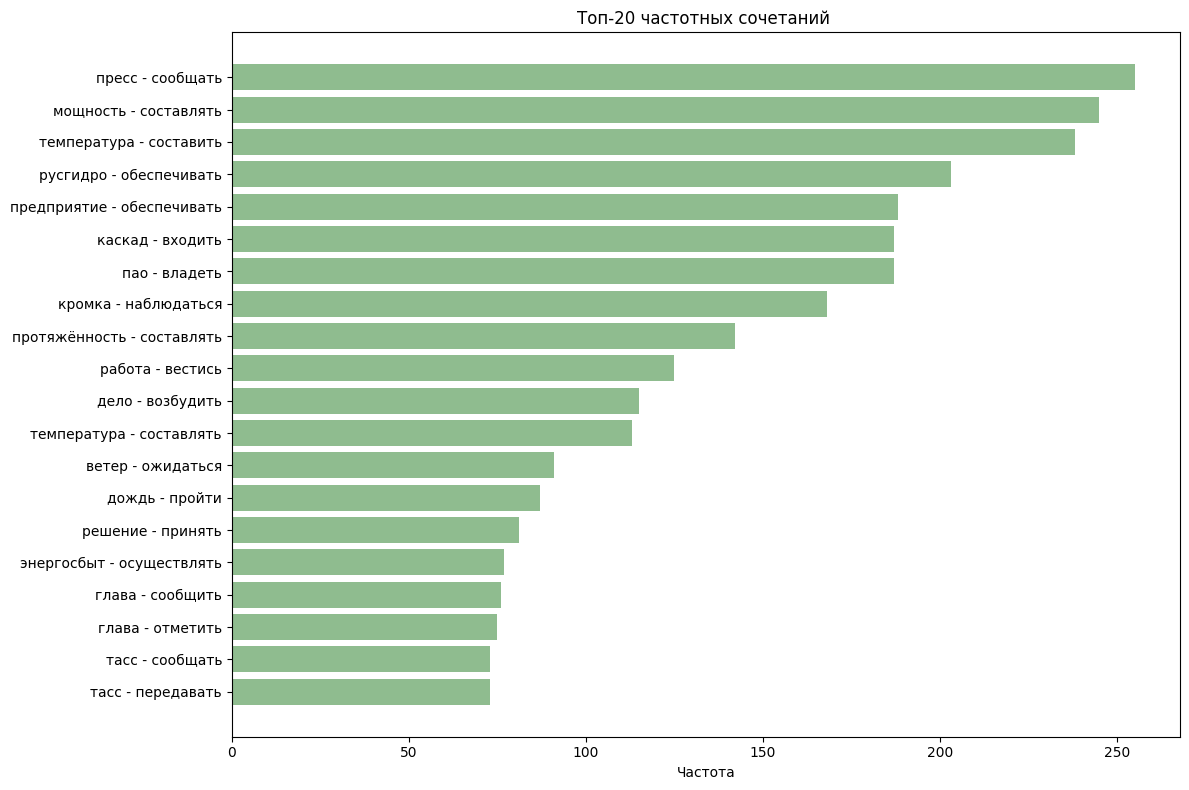

In [ ]:
def visualize_results(counter, top_n=20):

    top_pairs = counter.most_common(top_n)

    labels = [f"{subj} - {pred}" for (subj, pred), _ in top_pairs]
    values = [count for _, count in top_pairs]

    plt.figure(figsize=(12, 8))
    plt.barh(labels[::-1], values[::-1], color="darkseagreen")

    plt.xlabel("Частота")
    plt.title(f"Топ-{top_n} частотных сочетаний ")

    plt.tight_layout()
    plt.show()

visualize_results(cooccurrences, top_n=20)

### Функция для построения гистограммы распределения частот всех пар

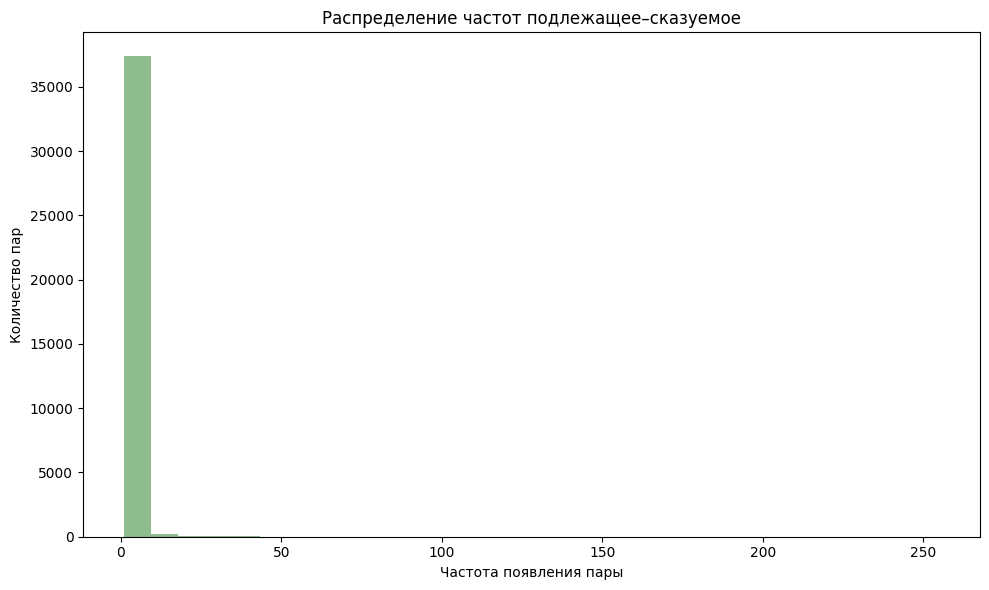

In [ ]:
def visualize_frequency_distribution(counter):

    frequencies = list(counter.values())

    plt.figure(figsize=(10, 6))
    plt.hist(frequencies, bins=30, color="darkseagreen")

    plt.xlabel("Частота появления пары")
    plt.ylabel("Количество пар")
    plt.title("Распределение частот подлежащее–сказуемое")

    plt.tight_layout()
    plt.show()

visualize_frequency_distribution(cooccurrences)

### Функция для визуализации топ-подлежащих

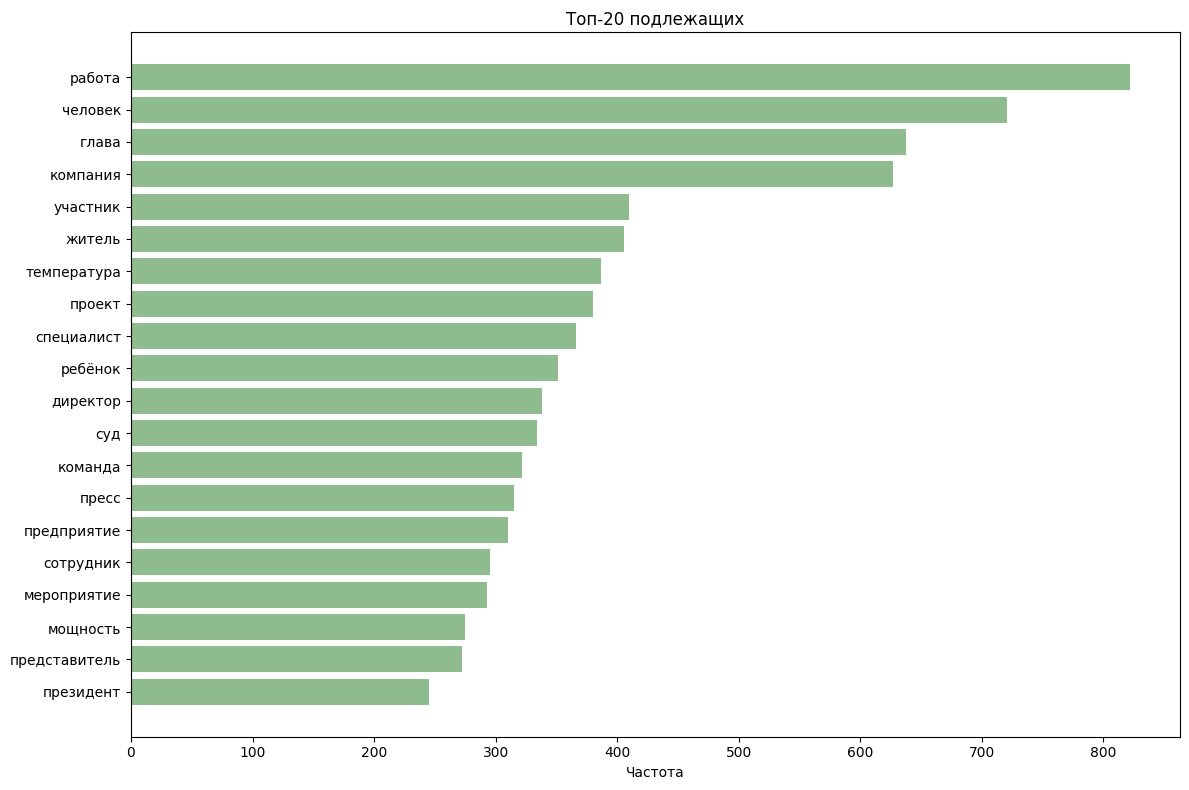

In [ ]:
def visualize_top_subjects(counter, top_n=20):

    subject_counter = Counter()

    for (subject, predicate), count in counter.items():
      if subject and subject.strip() and subject.isalpha():
        subject_counter[subject] += count

    top_subjects = subject_counter.most_common(top_n)

    labels = [subj for subj, _ in top_subjects]
    values = [count for _, count in top_subjects]

    plt.figure(figsize=(12, 8))
    plt.barh(labels[::-1], values[::-1], color="darkseagreen")

    plt.xlabel("Частота")
    plt.title(f"Топ-{top_n} подлежащих")

    plt.tight_layout()
    plt.show()

visualize_top_subjects(cooccurrences, top_n=20)

### Функция для визуализации топ-сказуемых

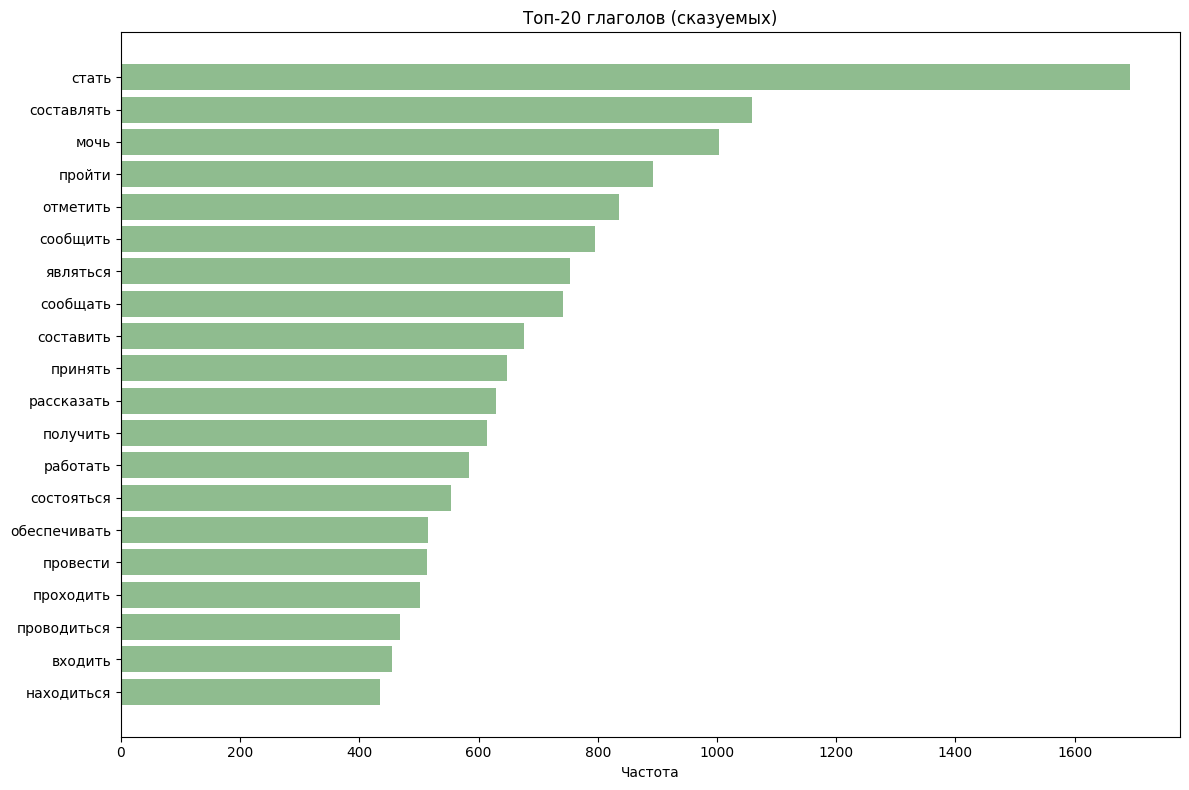

In [ ]:
def visualize_top_verbs(counter, top_n=20):

    verb_counter = Counter()

    for (subject, predicate), count in counter.items():
        verb_counter[predicate] += count

    top_verbs = verb_counter.most_common(top_n)

    labels = [verb for verb, _ in top_verbs]
    values = [count for _, count in top_verbs]

    plt.figure(figsize=(12, 8))
    plt.barh(labels[::-1], values[::-1], color="darkseagreen")

    plt.xlabel("Частота")
    plt.title(f"Топ-{top_n} глаголов (сказуемых)")

    plt.tight_layout()
    plt.show()

visualize_top_verbs(cooccurrences, top_n=20)